# ZeRO Stages on 32 Virtual GPUs
**ERA V5 -- Session assignment (12 Sep 2026)**

**Task:** build 32 virtual GPUs, run a demo model on them, simulate ZeRO-1, ZeRO-2 and ZeRO-3, show how memory and communication change, and check the results against the ZeRO paper.

**What this notebook does**
1. Builds a `VirtualCluster` of **32 GPUs (4 nodes x 8 GPUs)**. Each GPU is an object that holds real PyTorch tensors, and its memory is measured byte by byte from the tensors it actually holds.
2. Implements NCCL-style collectives (**all-reduce, reduce-scatter, all-gather**) and logs how much data each GPU sends.
3. Trains the same residual-MLP on the same data four times: **DDP (stage 0), ZeRO-1, ZeRO-2, ZeRO-3**.
4. Checks the following:
   * all four runs produce **bit-identical weights** (ZeRO is supposed to change memory, not the maths)
   * measured memory matches the paper's formulas **exactly**
   * communication comes to **2Ψ, 2Ψ, 2Ψ, 3Ψ** as the paper says
   * the formulas reproduce **Table 1 of the ZeRO paper** and the **30B-model numbers from the lecture** (447 -> 153 -> 104 -> 55 GiB on 8 GPUs)
5. Ends with the pros and cons of each stage and how I'd choose between them.

Runs on CPU only (Colab or a laptop). The whole notebook takes about a minute.

## 1. Background in one page

### 1.1 Where the memory goes: 16 bytes per parameter
With mixed-precision Adam, each parameter Ψ costs:

| What | dtype | bytes |
|---|---|---|
| working weights (used in forward/backward) | bf16 | 2 |
| gradients | bf16 | 2 |
| master weights | fp32 | 4 |
| Adam momentum `m` | fp32 | 4 |
| Adam variance `v` | fp32 | 4 |
| **total** | | **16** (the paper calls the optimizer part *K = 12*) |

So a 30B model needs 30e9 x 16 bytes = **447 GiB** before a single activation is stored. That doesn't fit on an 80 GB card.

### 1.2 The three collectives
* **All-reduce:** every GPU ends up with the sum (or average) of everyone's tensor. This is how DDP averages gradients.
* **Reduce-scatter:** the same sum, but GPU *i* keeps only slice *i* of the result.
* **All-gather:** GPU *i* contributes slice *i*, and everyone ends up with the full tensor.
* **All-reduce = reduce-scatter + all-gather.** This identity is why ZeRO-1/2 cost no extra communication. With a ring, each GPU sends 2(N-1)/N*M for an all-reduce and (N-1)/N*M for each of the other two, where M is the size of the full tensor.

### 1.3 Data parallelism and the ZeRO stages
In **DDP** every GPU keeps a full copy of all 16 bytes/param. That's N identical copies, which is pure redundancy. ZeRO removes the redundancy step by step:

| Stage | What is sharded across N GPUs | Memory per GPU | Comm per step |
|---|---|---|---|
| 0 (DDP) | nothing | 16Ψ | 2Ψ (all-reduce grads) |
| ZeRO-1 (P_os) | optimizer states (12 of 16 bytes) | 4Ψ + 12Ψ/N | 2Ψ (reduce-scatter grads + all-gather params) |
| ZeRO-2 (P_os+g) | + gradients | 2Ψ + 14Ψ/N | 2Ψ (same as ZeRO-1, but done during backward) |
| ZeRO-3 (P_os+g+p) | + the weights themselves | 16Ψ/N | **3Ψ** (all-gather in fwd + all-gather in bwd + reduce-scatter grads) |

## 2. Setup
The simulator is in one file, `zero_sim.py`. The next cell writes it to disk so the notebook runs anywhere (it's the same file as in the GitHub repo).

In [1]:
%%writefile zero_sim.py
"""
zero_sim.py - 32 virtual GPUs + DDP / ZeRO-1 / ZeRO-2 / ZeRO-3, in plain PyTorch on CPU.

Every "GPU" is a VirtualGPU object that owns real tensors. Memory is measured by summing
the bytes of the tensors each GPU holds at each moment (not by a formula), so the numbers
we compare against the ZeRO paper come from what the code actually stores.

Mixed precision follows the ZeRO paper:
    params (bf16) 2 bytes + grads (bf16) 2 bytes + Adam states in fp32 (master 4 + m 4 + v 4) = 16 bytes / param
"""
from __future__ import annotations

import math

import torch
import torch.nn.functional as F

# ----------------------------------------------------------------------------------------
# 1. Virtual GPUs
# ----------------------------------------------------------------------------------------
PARAM_DTYPE = torch.bfloat16    # 2 bytes
GRAD_DTYPE = torch.bfloat16     # 2 bytes
MASTER_DTYPE = torch.float32    # 4 bytes each for master weights, Adam m, Adam v

CATEGORIES = ["params", "grads", "optim", "activations", "gathered_params", "grad_temp"]


class OutOfMemory(RuntimeError):
    pass


class VirtualGPU:
    """A fake GPU: a named tensor store with byte-exact memory accounting."""

    def __init__(self, rank: int, node: int, capacity_bytes: int | None = None):
        self.rank, self.node, self.capacity = rank, node, capacity_bytes
        self.store: dict[str, tuple[str, torch.Tensor]] = {}
        self.used = {c: 0 for c in CATEGORIES}
        self.peak_total = 0
        self.peak_by_cat = dict(self.used)
        self.track = False            # record a memory timeline (used for rank 0 plots)
        self.timeline: list[dict] = []

    # --- allocation --------------------------------------------------------------------
    def alloc(self, name: str, tensor: torch.Tensor, category: str) -> torch.Tensor:
        if name in self.store:
            self.free(name)
        self.store[name] = (category, tensor)
        self.used[category] += tensor.numel() * tensor.element_size()
        self._update(f"+{name}")
        return tensor

    def free(self, name: str):
        cat, t = self.store.pop(name)
        self.used[cat] -= t.numel() * t.element_size()
        self._update(f"-{name}")

    def get(self, name: str) -> torch.Tensor:
        return self.store[name][1]

    @property
    def total(self) -> int:
        return sum(self.used.values())

    def model_state_bytes(self) -> int:
        return self.used["params"] + self.used["grads"] + self.used["optim"]

    def _update(self, label: str):
        tot = self.total
        if self.capacity is not None and tot > self.capacity:
            raise OutOfMemory(
                f"GPU{self.rank}: tried to hold {tot/2**20:.2f} MiB, capacity {self.capacity/2**20:.2f} MiB"
            )
        if tot > self.peak_total:
            self.peak_total, self.peak_by_cat = tot, dict(self.used)
        if self.track:
            self.timeline.append({"event": label, **self.used, "total": tot})

    def reset_peak(self):
        self.peak_total, self.peak_by_cat = self.total, dict(self.used)


class VirtualCluster:
    """N virtual GPUs split into nodes, plus NCCL-style collectives with a communication log.

    Communication volume uses ring algorithms (what NCCL uses for large messages):
        all-reduce     : each rank sends 2(N-1)/N * M bytes
        reduce-scatter : each rank sends  (N-1)/N * M bytes
        all-gather     : each rank sends  (N-1)/N * M bytes   (M = size of the full tensor)
    """

    def __init__(self, world_size=32, gpus_per_node=8, capacity_bytes=None,
                 nvlink_gbps=450.0, infiniband_gbps=50.0):
        self.N = world_size
        self.gpus_per_node = gpus_per_node
        self.gpus = [VirtualGPU(r, r // gpus_per_node, capacity_bytes) for r in range(world_size)]
        self.num_nodes = math.ceil(world_size / gpus_per_node)
        # bandwidths in GB/s (numbers used in the lecture: NVLink ~450 GB/s, InfiniBand ~10x slower)
        self.bottleneck_gbps = nvlink_gbps if self.num_nodes == 1 else infiniband_gbps
        self.comm_log: list[dict] = []
        self.phase = ""

    def __len__(self):
        return self.N

    # --- helpers -----------------------------------------------------------------------
    @staticmethod
    def _sum(tensors):
        # Same reduction order for every collective -> results are bit-identical across stages.
        acc = tensors[0].to(torch.float32).clone()
        for t in tensors[1:]:
            acc += t.to(torch.float32)
        return acc

    def _log(self, op, tag, full_numel, dtype, factor):
        elsize = torch.empty((), dtype=dtype).element_size()
        per_rank_elems = factor * (self.N - 1) / self.N * full_numel
        per_rank_bytes = per_rank_elems * elsize
        self.comm_log.append({
            "op": op, "tag": tag, "phase": self.phase, "full_numel": full_numel,
            "elems_sent_per_rank": per_rank_elems, "bytes_sent_per_rank": per_rank_bytes,
            "est_seconds": per_rank_bytes / (self.bottleneck_gbps * 1e9),
        })

    # --- collectives -------------------------------------------------------------------
    def all_reduce(self, tensors, tag="", average=True):
        """Every rank ends with the (averaged) sum of everyone's tensor."""
        assert len(tensors) == self.N
        s = self._sum(tensors)
        if average:
            s /= self.N
        self._log("all_reduce", tag, tensors[0].numel(), tensors[0].dtype, 2)
        return [s.to(t.dtype) for t in tensors]

    def reduce_scatter(self, tensors, tag="", average=True):
        """Same reduction as all-reduce, but rank r keeps only slice r of the result."""
        assert len(tensors) == self.N and tensors[0].numel() % self.N == 0
        s = self._sum(tensors)
        if average:
            s /= self.N
        self._log("reduce_scatter", tag, tensors[0].numel(), tensors[0].dtype, 1)
        return [c.to(tensors[0].dtype).clone() for c in s.chunk(self.N)]

    def all_gather(self, shards, tag=""):
        """Rank r contributes shard r; every rank ends with the concatenation of all shards."""
        assert len(shards) == self.N
        full = torch.cat(shards)
        self._log("all_gather", tag, full.numel(), full.dtype, 1)
        return [full.clone() for _ in range(self.N)]

    # --- reporting ---------------------------------------------------------------------
    def comm_summary(self, psi, steps=1):
        """Communication per rank per step in units of Psi (with the (N-1)/N factor removed)."""
        tot = sum(e["elems_sent_per_rank"] for e in self.comm_log) / steps
        return tot / psi * self.N / (self.N - 1)


# ----------------------------------------------------------------------------------------
# 2. Demo model: a residual MLP split into "units" (one unit = one layer = one FSDP/ZeRO-3 unit)
# ----------------------------------------------------------------------------------------
def make_model_spec(d_in=64, d_hidden=256, n_hidden=8, n_classes=10):
    spec = [{"name": "in_proj", "kind": "in", "shapes": [(d_hidden, d_in), (d_hidden,)]}]
    for i in range(n_hidden):
        spec.append({"name": f"block{i}", "kind": "res", "shapes": [(d_hidden, d_hidden), (d_hidden,)]})
    spec.append({"name": "head", "kind": "head", "shapes": [(n_classes, d_hidden), (n_classes,)]})
    return spec


def unit_numel(unit):
    return sum(math.prod(s) for s in unit["shapes"])


def unflatten(flat, shapes):
    out, off = [], 0
    for s in shapes:
        n = math.prod(s)
        out.append(flat[off:off + n].view(s))
        off += n
    return out


def unit_forward(kind, W, b, x):
    if kind == "in":
        return F.gelu(x @ W.T + b)
    if kind == "res":
        return x + F.gelu(x @ W.T + b)
    return x @ W.T + b  # head -> logits


def init_units(spec, world_size, seed=0):
    """Full fp32 params per unit, flattened and padded to a multiple of world_size."""
    g = torch.Generator().manual_seed(seed)
    flats = []
    for u in spec:
        parts = []
        scale = {"in": 1.0, "res": 0.5, "head": 0.1}[u["kind"]]
        for s in u["shapes"]:
            if len(s) == 2:
                parts.append(torch.randn(s, generator=g) * (scale / math.sqrt(s[1])))
            else:
                parts.append(torch.zeros(s))
        flat = torch.cat([p.flatten() for p in parts])
        pad = (-flat.numel()) % world_size
        flats.append(torch.cat([flat, torch.zeros(pad)]))
    return flats


class SyntheticData:
    """A fixed random 'teacher' network labels random inputs. Each rank gets a different micro-batch."""

    def __init__(self, d_in=64, n_classes=10, seed=123):
        g = torch.Generator().manual_seed(seed)
        self.d_in = d_in
        self.teacher = torch.randn(n_classes, d_in, generator=g)

    def batch(self, step, rank, micro_bs):
        g = torch.Generator().manual_seed(10_000 * step + rank)
        x = torch.randn(micro_bs, self.d_in, generator=g)
        y = (x @ self.teacher.T).argmax(dim=1)
        return x, y


# ----------------------------------------------------------------------------------------
# 3. Optimizer (AdamW, element-wise -> a sharded update equals the full update exactly)
# ----------------------------------------------------------------------------------------
def adamw_(master, m, v, g, step, lr, b1=0.9, b2=0.95, eps=1e-8, wd=0.0):
    m.mul_(b1).add_(g, alpha=1 - b1)
    v.mul_(b2).addcmul_(g, g, value=1 - b2)
    denom = (v / (1 - b2 ** step)).sqrt_().add_(eps)
    if wd:
        master.mul_(1 - lr * wd)
    master.addcdiv_(m, denom, value=-lr / (1 - b1 ** step))


# ----------------------------------------------------------------------------------------
# 4. The trainer: one class, four behaviours selected by `stage`
#    stage 0 = plain data parallel (DDP), 1 = ZeRO-1 (P_os), 2 = ZeRO-2 (P_os+g), 3 = ZeRO-3 (P_os+g+p)
# ----------------------------------------------------------------------------------------
STAGE_NAMES = {0: "DDP (no ZeRO)", 1: "ZeRO-1", 2: "ZeRO-2", 3: "ZeRO-3"}


class ZeroTrainer:
    def __init__(self, cluster: VirtualCluster, stage: int, spec=None, data=None,
                 lr=3e-3, micro_bs=16, seed=0):
        assert stage in (0, 1, 2, 3)
        self.C, self.stage = cluster, stage
        self.spec = spec or make_model_spec()
        self.data = data or SyntheticData()
        self.lr, self.micro_bs = lr, micro_bs
        self.step_num = 0
        N = cluster.N

        full = init_units(self.spec, N, seed)
        self.psi = sum(unit_numel(u) for u in self.spec)       # real parameter count
        self.psi_padded = sum(f.numel() for f in full)          # what is actually stored
        self.shard_sizes = [f.numel() // N for f in full]

        for gpu in cluster.gpus:
            r = gpu.rank
            for u, f in enumerate(full):
                shard = f.chunk(N)[r]
                # bf16 working parameters: full copy (stage 0-2) or only my shard (stage 3)
                p = f if stage < 3 else shard
                gpu.alloc(f"p{u}", p.to(PARAM_DTYPE).clone(), "params")
                # fp32 optimizer states: full (stage 0) or my shard (stage 1-3)
                o = f if stage == 0 else shard
                gpu.alloc(f"master{u}", o.to(MASTER_DTYPE).clone(), "optim")
                gpu.alloc(f"m{u}", torch.zeros_like(o, dtype=MASTER_DTYPE), "optim")
                gpu.alloc(f"v{u}", torch.zeros_like(o, dtype=MASTER_DTYPE), "optim")
                # bf16 gradient buffer: full (stage 0-1) or my shard (stage 2-3)
                gsize = f.numel() if stage < 2 else shard.numel()
                gpu.alloc(f"g{u}", torch.zeros(gsize, dtype=GRAD_DTYPE), "grads")
            gpu.reset_peak()

    # --- parameter access ----------------------------------------------------------------
    def _materialize(self, u, phase):
        """Return every rank's full bf16 params for unit u. ZeRO-3 must all-gather them first."""
        gpus = self.C.gpus
        if self.stage < 3:
            return [g.get(f"p{u}") for g in gpus]
        fulls = self.C.all_gather([g.get(f"p{u}") for g in gpus], tag=f"{phase}:params:{self.spec[u]['name']}")
        for g, t in zip(gpus, fulls):
            g.alloc(f"gathered{u}", t, "gathered_params")
        return fulls

    def _release(self, u):
        if self.stage == 3:
            for g in self.C.gpus:
                g.free(f"gathered{u}")

    # --- one training step -----------------------------------------------------------------
    def step(self):
        C, N, gpus = self.C, self.C.N, self.C.gpus
        self.step_num += 1
        units = self.spec
        batches = [self.data.batch(self.step_num, r, self.micro_bs) for r in range(N)]
        x = [b[0].to(PARAM_DTYPE) for b in batches]

        # ---------------- forward (all ranks in lock-step, unit by unit) ----------------
        C.phase = "forward"
        for u, unit in enumerate(units):
            params = self._materialize(u, "fwd")
            for r, g in enumerate(gpus):
                g.alloc(f"act{u}", x[r], "activations")       # saved input for backward
                W, b = unflatten(params[r], unit["shapes"])
                with torch.no_grad():
                    x[r] = unit_forward(unit["kind"], W, b, x[r])
            self._release(u)

        losses, grad_out = [], []
        for r in range(N):
            logits = x[r].detach().float().requires_grad_(True)
            loss = F.cross_entropy(logits, batches[r][1])
            (gl,) = torch.autograd.grad(loss, logits)
            losses.append(loss.item())
            grad_out.append(gl.to(PARAM_DTYPE))

        # ---------------- backward ----------------
        C.phase = "backward"
        for u in reversed(range(len(units))):
            unit = units[u]
            params = self._materialize(u, "bwd")
            for r, g in enumerate(gpus):
                xin = g.get(f"act{u}").detach().requires_grad_(u > 0)
                p = params[r].detach().clone().requires_grad_(True)
                W, b = unflatten(p, unit["shapes"])
                with torch.enable_grad():
                    y = unit_forward(unit["kind"], W, b, xin)
                    wrt = [xin, p] if u > 0 else [p]
                    grads = torch.autograd.grad(y, wrt, grad_out[r])
                g.free(f"act{u}")
                grad_out[r] = grads[0] if u > 0 else None
                g.alloc(f"gtmp{u}", grads[-1].to(GRAD_DTYPE), "grad_temp")   # this unit's full grad
            self._release(u)
            self._on_unit_grad_ready(u)

        if self.stage == 1:   # ZeRO-1 reduce-scatters the full grad buffers once backward is done
            C.phase = "backward"
            for u in range(len(units)):
                shards = C.reduce_scatter([g.get(f"g{u}") for g in gpus], tag=f"grads:{units[u]['name']}")
                S = self.shard_sizes[u]
                for r, g in enumerate(gpus):
                    g.get(f"g{u}")[r * S:(r + 1) * S].copy_(shards[r])

        # ---------------- optimizer step ----------------
        C.phase = "step"
        for u in range(len(units)):
            S = self.shard_sizes[u]
            for r, g in enumerate(gpus):
                grad = g.get(f"g{u}")
                if self.stage == 1:
                    grad = grad[r * S:(r + 1) * S]        # only my slice is averaged / needed
                adamw_(g.get(f"master{u}"), g.get(f"m{u}"), g.get(f"v{u}"),
                       grad.to(MASTER_DTYPE), self.step_num, self.lr)
                if self.stage in (0, 3):                   # my bf16 params come straight from my master copy
                    g.get(f"p{u}").copy_(g.get(f"master{u}").to(PARAM_DTYPE))
            if self.stage in (1, 2):                       # everyone updated a different slice -> all-gather
                fulls = C.all_gather([g.get(f"master{u}").to(PARAM_DTYPE) for g in gpus],
                                     tag=f"params:{units[u]['name']}")
                for g, t in zip(gpus, fulls):
                    g.get(f"p{u}").copy_(t)
            for g in gpus:
                g.get(f"g{u}").zero_()
        C.phase = ""
        return sum(losses) / N

    def _on_unit_grad_ready(self, u):
        gpus = self.C.gpus
        name = self.spec[u]["name"]
        if self.stage == 0:        # DDP: all-reduce the bucket as soon as it is ready
            red = self.C.all_reduce([g.get(f"gtmp{u}") for g in gpus], tag=f"grads:{name}")
            for g, t in zip(gpus, red):
                g.get(f"g{u}").copy_(t)
        elif self.stage == 1:      # ZeRO-1: keep the full local grad, reduce later
            for g in gpus:
                g.get(f"g{u}").copy_(g.get(f"gtmp{u}"))
        else:                      # ZeRO-2/3: reduce-scatter now, keep only my shard
            shards = self.C.reduce_scatter([g.get(f"gtmp{u}") for g in gpus], tag=f"grads:{name}")
            for g, t in zip(gpus, shards):
                g.get(f"g{u}").copy_(t)
        for g in gpus:
            g.free(f"gtmp{u}")

    # --- inspection ------------------------------------------------------------------------
    def full_master_params(self):
        """Stitch the fp32 master weights back together from all ranks (for equivalence checks)."""
        gpus, out = self.C.gpus, []
        for u in range(len(self.spec)):
            if self.stage == 0:
                out.append(gpus[0].get(f"master{u}").clone())
            else:
                out.append(torch.cat([g.get(f"master{u}") for g in gpus]))
        return torch.cat(out)

    def ranks_in_sync(self):
        """In stages 0-2 every rank must hold identical bf16 params after the step."""
        if self.stage == 3:
            return True
        ref = self.C.gpus[0]
        return all(torch.equal(ref.get(f"p{u}"), g.get(f"p{u}"))
                   for g in self.C.gpus[1:] for u in range(len(self.spec)))


# ----------------------------------------------------------------------------------------
# 5. The ZeRO paper's formulas (Rajbhandari et al., 2020, Section 5 / Table 1)
# ----------------------------------------------------------------------------------------
def zero_model_state_bytes(psi, N, stage, K=12):
    """Per-GPU model-state memory in bytes (2 bytes params + 2 bytes grads + K bytes optimizer)."""
    if stage == 0:
        return (2 + 2 + K) * psi
    if stage == 1:
        return 2 * psi + 2 * psi + K * psi / N
    if stage == 2:
        return 2 * psi + (2 + K) * psi / N
    return (2 + 2 + K) * psi / N


def zero_comm_psi(stage):
    """Communication volume per step per rank, in units of Psi (paper Section 7)."""
    return {0: 2.0, 1: 2.0, 2: 2.0, 3: 3.0}[stage]


def max_params_that_fit(gpu_bytes, N, stage, K=12):
    return gpu_bytes / zero_model_state_bytes(1, N, stage, K)

Overwriting zero_sim.py


In [2]:
import importlib, time, math
import torch
import pandas as pd
import matplotlib.pyplot as plt
import zero_sim; importlib.reload(zero_sim)
from zero_sim import *

torch.manual_seed(0)
pd.set_option("display.precision", 4)
MiB = 2**20; GiB = 2**30
print("torch", torch.__version__)

torch 2.14.0+cu130


## 3. Build 32 virtual GPUs
32 GPUs spread across **4 nodes x 8 GPUs**. Inside a node GPUs talk over NVLink (~450 GB/s). Between nodes they use InfiniBand, which is about 10x slower (~50 GB/s). A ring that spans nodes is limited by its slowest link, so that's the speed used for time estimates.

In [3]:
cluster = VirtualCluster(world_size=32, gpus_per_node=8)
topo = pd.DataFrame([{"rank": g.rank, "node": g.node} for g in cluster.gpus])
print(f"{cluster.N} virtual GPUs on {cluster.num_nodes} nodes; ring bottleneck = {cluster.bottleneck_gbps} GB/s")
topo.groupby("node")["rank"].apply(lambda r: f"GPU {r.min()}-{r.max()}").to_frame("GPUs")

32 virtual GPUs on 4 nodes; ring bottleneck = 50.0 GB/s


,GPUs
node,
0,GPU 0-7
1,GPU 8-15
2,GPU 16-23
3,GPU 24-31


### 3.1 Checking the collectives
Before building anything on top of them, check the key identity from the lecture: **reduce-scatter followed by all-gather gives exactly the same result as all-reduce.**

In [4]:
c = VirtualCluster(32)
local = [torch.randn(64) for _ in range(32)]          # each GPU has its own "gradient"
ar = c.all_reduce(local, tag="demo")
rs = c.reduce_scatter(local, tag="demo")              # each GPU gets 1/32 of the averaged result
ag = c.all_gather(rs, tag="demo")                     # ...and then everybody gets everything

print("reduce-scatter shard shape on each GPU:", tuple(rs[0].shape))
print("all_reduce == reduce_scatter + all_gather :", all(torch.equal(a, b) for a, b in zip(ar, ag)))
print("every GPU holds the same result          :", all(torch.equal(ar[0], t) for t in ar))
pd.DataFrame(c.comm_log)[["op", "full_numel", "elems_sent_per_rank"]]

reduce-scatter shard shape on each GPU: (2,)
all_reduce == reduce_scatter + all_gather : True
every GPU holds the same result          : True


,op,full_numel,elems_sent_per_rank
0,all_reduce,64,124.0
1,reduce_scatter,64,62.0
2,all_gather,64,62.0


The all-reduce sends 2*31/32*64 = 124 elements per GPU. Reduce-scatter and all-gather send 62 each, so together they cost the same as one all-reduce.

## 4. The demo model
A residual MLP: `in_proj -> 8 residual blocks (256x256) -> head`. Each layer is one **unit**. ZeRO-3 gathers and frees parameters one unit at a time (FSDP does the same). Every parameter tensor is flattened and padded to a multiple of 32 so it splits evenly into 32 shards.

Each GPU gets a different micro-batch of 16 examples (global batch = 32 x 16 = 512). Labels come from a fixed random "teacher" network, so the task can actually be learned.

In [5]:
spec = make_model_spec()
rows = [{"unit": u["name"], "shapes": u["shapes"], "params": unit_numel(u),
         "padded": unit_numel(u) + (-unit_numel(u)) % 32, "shard per GPU": (unit_numel(u) + (-unit_numel(u)) % 32) // 32}
        for u in spec]
df_model = pd.DataFrame(rows)
PSI = df_model["params"].sum(); PSI_PAD = df_model["padded"].sum()
print(f"Psi = {PSI:,} parameters  (padded to {PSI_PAD:,} for even sharding)")
df_model

Psi = 545,546 parameters  (padded to 545,568 for even sharding)


,unit,shapes,params,padded,shard per GPU
0,in_proj,"[(256, 64), (256,)]",16640,16640,520
1,block0,"[(256, 256), (256,)]",65792,65792,2056
2,block1,"[(256, 256), (256,)]",65792,65792,2056
3,block2,"[(256, 256), (256,)]",65792,65792,2056
4,block3,"[(256, 256), (256,)]",65792,65792,2056
5,block4,"[(256, 256), (256,)]",65792,65792,2056
6,block5,"[(256, 256), (256,)]",65792,65792,2056
7,block6,"[(256, 256), (256,)]",65792,65792,2056
8,block7,"[(256, 256), (256,)]",65792,65792,2056
9,head,"[(10, 256), (10,)]",2570,2592,81


## 5. Train the model with DDP, ZeRO-1, ZeRO-2 and ZeRO-3
Same seed, same data, 20 steps each. What each stage does in `ZeroTrainer.step()`:

| | forward | backward | optimizer step |
|---|---|---|---|
| **DDP** | local full params | all-reduce each unit's grads as they're ready | full Adam on every GPU |
| **ZeRO-1** | local full params | keep full local grads, **reduce-scatter** at the end | Adam on **my 1/32 slice**, then **all-gather** params |
| **ZeRO-2** | local full params | **reduce-scatter** each unit immediately and keep only my grad shard | Adam on my slice, then **all-gather** params |
| **ZeRO-3** | **all-gather** unit -> compute -> free | **all-gather** again -> compute -> **reduce-scatter** grads -> free | Adam on my slice. No gather needed: I only own my shard |

In [6]:
STEPS = 20
runs = {}
for stage in range(4):
    c = VirtualCluster(32, gpus_per_node=8)
    tr = ZeroTrainer(c, stage)
    t0 = time.time()
    losses = [tr.step() for _ in range(STEPS)]
    runs[stage] = dict(cluster=c, trainer=tr, losses=losses, secs=time.time() - t0)
    print(f"{STAGE_NAMES[stage]:14s} loss {losses[0]:.4f} -> {losses[-1]:.4f}   "
          f"all ranks in sync: {tr.ranks_in_sync()}   ({runs[stage]['secs']:.1f}s)")

DDP (no ZeRO)  loss 2.3137 -> 0.8468   all ranks in sync: True   (5.7s)


ZeRO-1         loss 2.3137 -> 0.8468   all ranks in sync: True   (4.5s)


ZeRO-2         loss 2.3137 -> 0.8468   all ranks in sync: True   (4.2s)


ZeRO-3         loss 2.3137 -> 0.8468   all ranks in sync: True   (4.0s)


### 5.1 Memory per GPU (measured on GPU 0)

In [7]:
rows = []
for s, r in runs.items():
    g = r["cluster"].gpus[0]
    rows.append({
        "stage": STAGE_NAMES[s],
        "params (bf16)": g.used["params"] / MiB,
        "grads (bf16)": g.used["grads"] / MiB,
        "optimizer (fp32 x3)": g.used["optim"] / MiB,
        "model states measured": g.model_state_bytes() / MiB,
        "paper formula": zero_model_state_bytes(PSI_PAD, 32, s) / MiB,
        "peak incl. activations & temp buffers": g.peak_total / MiB,
        "vs DDP": g.model_state_bytes() / runs[0]["cluster"].gpus[0].model_state_bytes(),
    })
df_mem = pd.DataFrame(rows).set_index("stage")
df_mem.style.format("{:.3f}").format("{:.1%}", subset=["vs DDP"])

,params (bf16),grads (bf16),optimizer (fp32 x3),model states measured,paper formula,peak incl. activations & temp buffers,vs DDP
stage,,,,,,,
DDP (no ZeRO),1.041,1.041,6.244,8.325,8.325,8.507,100.0%
ZeRO-1,1.041,1.041,0.195,2.276,2.276,2.458,27.3%
ZeRO-2,1.041,0.033,0.195,1.268,1.268,1.450,15.2%
ZeRO-3,0.033,0.033,0.195,0.260,0.260,0.568,3.1%


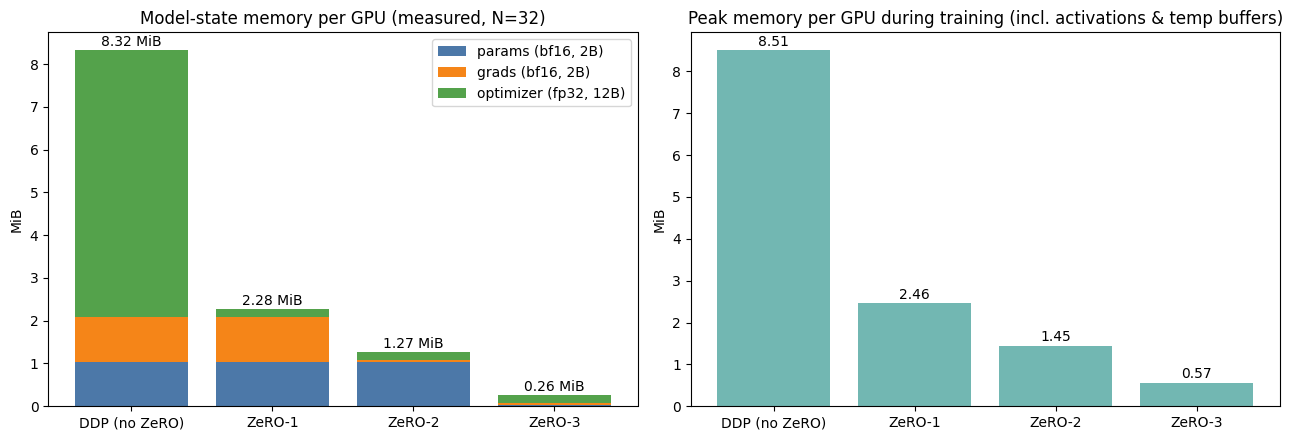

In [8]:
cats = ["params", "grads", "optim"]
labels = {"params": "params (bf16, 2B)", "grads": "grads (bf16, 2B)", "optim": "optimizer (fp32, 12B)"}
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
bottom = [0] * 4
names = [STAGE_NAMES[s] for s in range(4)]
for cat, col in zip(cats, ["#4C78A8", "#F58518", "#54A24B"]):
    vals = [runs[s]["cluster"].gpus[0].used[cat] / MiB for s in range(4)]
    ax[0].bar(names, vals, bottom=bottom, label=labels[cat], color=col)
    bottom = [b + v for b, v in zip(bottom, vals)]
for i, b in enumerate(bottom):
    ax[0].text(i, b + 0.1, f"{b:.2f} MiB", ha="center")
ax[0].set_title("Model-state memory per GPU (measured, N=32)"); ax[0].set_ylabel("MiB"); ax[0].legend()

peak = [runs[s]["cluster"].gpus[0].peak_total / MiB for s in range(4)]
ax[1].bar(names, peak, color="#72B7B2")
for i, p in enumerate(peak):
    ax[1].text(i, p + 0.1, f"{p:.2f}", ha="center")
ax[1].set_title("Peak memory per GPU during training (incl. activations & temp buffers)"); ax[1].set_ylabel("MiB")
plt.tight_layout(); plt.show()

### 5.2 Memory over time within one step (GPU 0)
This is the clearest view of what each stage is doing. I record GPU 0's memory after every allocate/free during one extra step.
* **DDP / ZeRO-1:** a flat, high line. The full weights, grads (and in DDP the full optimizer) sit there the whole time.
* **ZeRO-2:** the base is lower (grads are sharded), with small bumps where one unit's full gradient exists just long enough to be reduce-scattered.
* **ZeRO-3:** the lowest base. Each unit's weights are gathered, used and freed, so the spikes are the price of that low baseline.

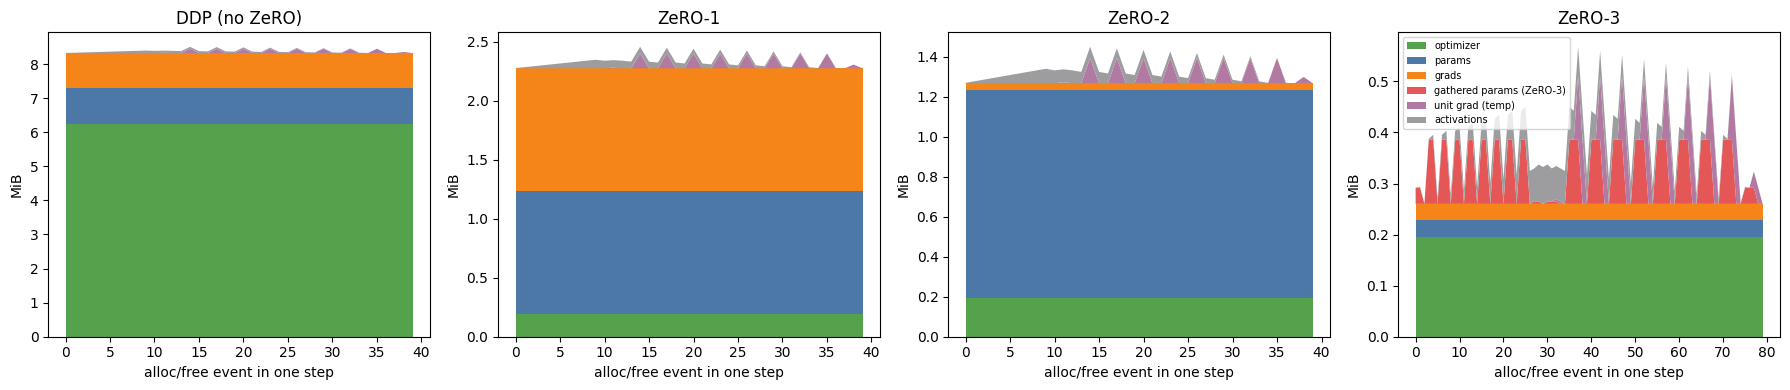

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=False)
for s, ax in zip(range(4), axes):
    g = runs[s]["cluster"].gpus[0]
    g.timeline.clear(); g.track = True
    runs[s]["trainer"].step()
    g.track = False
    tl = pd.DataFrame(g.timeline)
    for cat in ["params", "grads", "optim", "activations", "gathered_params", "grad_temp"]:
        tl[cat] = tl[cat] / MiB
    ax.stackplot(range(len(tl)), tl["optim"], tl["params"], tl["grads"], tl["gathered_params"],
                 tl["grad_temp"], tl["activations"],
                 labels=["optimizer", "params", "grads", "gathered params (ZeRO-3)", "unit grad (temp)", "activations"],
                 colors=["#54A24B", "#4C78A8", "#F58518", "#E45756", "#B279A2", "#9D9DA0"])
    ax.set_title(STAGE_NAMES[s]); ax.set_xlabel("alloc/free event in one step"); ax.set_ylabel("MiB")
axes[-1].legend(loc="upper left", fontsize=7)
plt.tight_layout(); plt.show()

### 5.3 Communication per step

In [10]:
rows = []
for s, r in runs.items():
    log = pd.DataFrame(r["cluster"].comm_log)
    steps = r["trainer"].step_num
    per = log.groupby(["phase", "op"])["elems_sent_per_rank"].sum() / steps / PSI_PAD * 32 / 31
    row = {"stage": STAGE_NAMES[s]}
    row.update({f"{p} / {o}": v for (p, o), v in per.items()})
    row["TOTAL (x Psi)"] = r["cluster"].comm_summary(PSI_PAD, steps)
    row["paper"] = zero_comm_psi(s)
    row["collective calls / step"] = len(log) / steps
    rows.append(row)
df_comm = pd.DataFrame(rows).set_index("stage").fillna(0)
order = ["forward / all_gather", "backward / all_reduce", "backward / reduce_scatter", "backward / all_gather", "step / all_gather"]
df_comm = df_comm[[c for c in order if c in df_comm] + ["TOTAL (x Psi)", "paper", "collective calls / step"]]
df_comm

,forward / all_gather,backward / all_reduce,backward / reduce_scatter,backward / all_gather,step / all_gather,TOTAL (x Psi),paper,collective calls / step
stage,,,,,,,,
DDP (no ZeRO),0.0,2.0,0.0,0.0,0.0,2.0,2.0,10.0
ZeRO-1,0.0,0.0,1.0,0.0,1.0,2.0,2.0,20.0
ZeRO-2,0.0,0.0,1.0,0.0,1.0,2.0,2.0,20.0
ZeRO-3,1.0,0.0,1.0,1.0,0.0,3.0,3.0,30.0


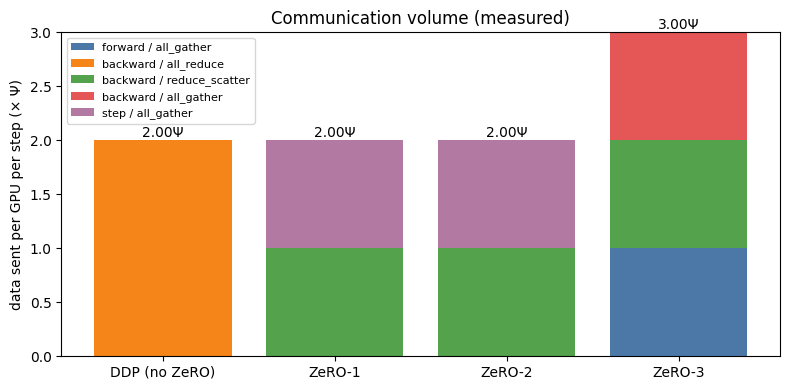

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
parts = [c for c in df_comm.columns if "/" in c]
bottom = [0] * 4
for p, col in zip(parts, ["#4C78A8", "#F58518", "#54A24B", "#E45756", "#B279A2"]):
    ax.bar(df_comm.index, df_comm[p], bottom=bottom, label=p, color=col)
    bottom = [b + v for b, v in zip(bottom, df_comm[p])]
for i, b in enumerate(bottom):
    ax.text(i, b + 0.03, f"{b:.2f}Ψ", ha="center")
ax.set_ylabel("data sent per GPU per step (x Ψ)"); ax.set_title("Communication volume (measured)")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

Two things stand out:
* **ZeRO-1 and ZeRO-2 cost the same bytes as DDP (2Ψ).** They just swap one all-reduce for a reduce-scatter plus an all-gather.
* **ZeRO-3 costs 1.5x (3Ψ)**, because the weights must be all-gathered twice (once in forward, once in backward). It also makes many more, smaller collective calls, which is more latency overhead in practice.

## 6. Verification: does this match what ZeRO actually does?

### 6.1 ZeRO must not change the maths
The paper's claim is that ZeRO removes redundancy **without changing the training result**. My check: the fp32 master weights, stitched back together from all 32 GPUs, must be **bit-identical** across the four runs, and so must the loss curves.

In [12]:
ref_params = runs[0]["trainer"].full_master_params()
checks = []
for s in range(4):
    t = runs[s]["trainer"]
    checks.append({"stage": STAGE_NAMES[s],
                   "losses identical to DDP": runs[s]["losses"] == runs[0]["losses"],
                   "master weights bit-identical to DDP": torch.equal(t.full_master_params(), ref_params),
                   "ranks hold identical params": t.ranks_in_sync(),
                   "measured states == formula": runs[s]["cluster"].gpus[0].model_state_bytes() == zero_model_state_bytes(PSI_PAD, 32, s),
                   "comm == paper": abs(runs[s]["cluster"].comm_summary(PSI_PAD, t.step_num) - zero_comm_psi(s)) < 1e-9})
df_checks = pd.DataFrame(checks).set_index("stage")
assert df_checks.all().all(), "a check failed"
df_checks

,losses identical to DDP,master weights bit-identical to DDP,ranks hold identical params,measured states == formula,comm == paper
stage,,,,,
DDP (no ZeRO),True,True,True,True,True
ZeRO-1,True,True,True,True,True
ZeRO-2,True,True,True,True,True
ZeRO-3,True,True,True,True,True


### 6.2 Is the distributed training actually correct?
As an independent check, I train the same model on **one device in plain fp32** with the full 512-example batch. The 32-GPU runs use bf16 weights and grads, so the numbers won't be bit-identical, but the loss curve should track it closely.

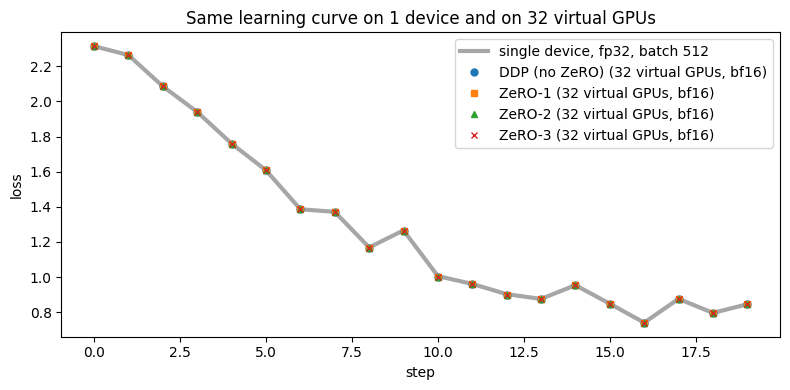

max |loss difference| vs fp32 reference: 0.0023767035454511642


In [13]:
def single_device_reference(steps, lr=3e-3, N=32, micro_bs=16):
    spec, data = make_model_spec(), SyntheticData()
    params = [p.clone() for p in init_units(spec, N, seed=0)]
    m = [torch.zeros_like(p) for p in params]; v = [torch.zeros_like(p) for p in params]
    out = []
    for step in range(1, steps + 1):
        xs, ys = zip(*[data.batch(step, r, micro_bs) for r in range(N)])
        x, y = torch.cat(xs), torch.cat(ys)
        leaves = [p.clone().requires_grad_(True) for p in params]
        h = x
        for u, leaf in zip(spec, leaves):
            W, b = unflatten(leaf, u["shapes"])
            h = unit_forward(u["kind"], W, b, h)
        loss = F.cross_entropy(h, y)
        grads = torch.autograd.grad(loss, leaves)
        for p, mm, vv, g in zip(params, m, v, grads):
            adamw_(p, mm, vv, g, step, lr)
        out.append(loss.item())
    return out

ref_losses = single_device_reference(STEPS)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ref_losses, "k-", lw=3, alpha=.35, label="single device, fp32, batch 512")
for s, mk in zip(range(4), ["o", "s", "^", "x"]):
    ax.plot(runs[s]["losses"][:STEPS], mk, ms=5, label=f"{STAGE_NAMES[s]} (32 virtual GPUs, bf16)")
ax.set_xlabel("step"); ax.set_ylabel("loss"); ax.legend(); ax.set_title("Same learning curve on 1 device and on 32 virtual GPUs")
plt.tight_layout(); plt.show()
print("max |loss difference| vs fp32 reference:", max(abs(a - b) for a, b in zip(ref_losses, runs[0]["losses"])))

### 6.3 Reproducing ZeRO paper Table 1
Table 1 of Rajbhandari et al. (2020) gives per-GPU model-state memory for a **7.5B model** (K = 12) at different data-parallel degrees N, in GB. My formula function should reproduce every entry.

In [14]:
paper_table1 = {  # N: (DDP, P_os, P_os+g, P_os+g+p)  in GB, from the paper
    1: (120, 120, 120, 120), 4: (120, 52.5, 41.3, 30), 16: (120, 35.6, 21.6, 7.5),
    64: (120, 31.4, 16.6, 1.88), 256: (120, 30.4, 15.4, 0.47), 1024: (120, 30.1, 15.1, 0.12)}
rows = []
for N, paper in paper_table1.items():
    mine = [zero_model_state_bytes(7.5e9, N, s) / 1e9 for s in range(4)]
    ok = all(abs(a - b) <= 0.051 + 0.01 * b for a, b in zip(mine, paper))
    rows.append({"N": N, **{f"{STAGE_NAMES[s]} (mine)": round(mine[s], 2) for s in range(4)},
                 "paper": paper, "match": ok})
df_t1 = pd.DataFrame(rows).set_index("N")
assert df_t1["match"].all()
df_t1

,DDP (no ZeRO) (mine),ZeRO-1 (mine),ZeRO-2 (mine),ZeRO-3 (mine),paper,match
N,,,,,,
1,120.0,120.00,120.00,120.00,"(120, 120, 120, 120)",True
4,120.0,52.50,41.25,30.00,"(120, 52.5, 41.3, 30)",True
16,120.0,35.62,21.56,7.50,"(120, 35.6, 21.6, 7.5)",True
64,120.0,31.41,16.64,1.88,"(120, 31.4, 16.6, 1.88)",True
256,120.0,30.35,15.41,0.47,"(120, 30.4, 15.4, 0.47)",True
1024,120.0,30.09,15.10,0.12,"(120, 30.1, 15.1, 0.12)",True


### 6.4 The lecture's 30B example
From the session: a 30B model on 8 GPUs needs **447 GiB** per GPU with plain DP, then **153 GiB (ZeRO-1)**, **104 GiB (ZeRO-2)** and **55 GiB (ZeRO-3)**. Below are the same numbers from my formula, plus what happens on 32 GPUs.

In [15]:
lecture = {0: 447, 1: 153, 2: 104, 3: 55}
rows = []
for s in range(4):
    rows.append({"stage": STAGE_NAMES[s],
                 "lecture, N=8 (GiB)": lecture[s],
                 "mine, N=8 (GiB)": zero_model_state_bytes(30e9, 8, s) / GiB,
                 "mine, N=32 (GiB)": zero_model_state_bytes(30e9, 32, s) / GiB,
                 "fits 80 GB card at N=32?": zero_model_state_bytes(30e9, 32, s) < 80e9,
                 "largest model on 80GB x 32 GPUs (B params)": max_params_that_fit(80e9, 32, s) / 1e9})
df_30b = pd.DataFrame(rows).set_index("stage")
assert all(abs(df_30b["lecture, N=8 (GiB)"] - df_30b["mine, N=8 (GiB)"]) < 1.0)
df_30b.style.format(precision=1)

,"lecture, N=8 (GiB)","mine, N=8 (GiB)","mine, N=32 (GiB)",fits 80 GB card at N=32?,largest model on 80GB x 32 GPUs (B params)
stage,,,,,
DDP (no ZeRO),447,447.0,447.0,False,5.0
ZeRO-1,153,153.7,122.2,False,18.3
ZeRO-2,104,104.8,68.1,True,32.8
ZeRO-3,55,55.9,14.0,True,160.0


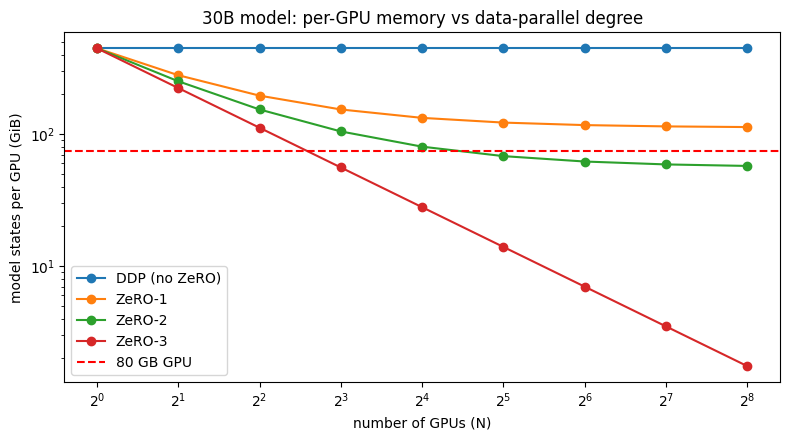

In [16]:
Ns = [1, 2, 4, 8, 16, 32, 64, 128, 256]
fig, ax = plt.subplots(figsize=(8, 4.5))
for s in range(4):
    ax.plot(Ns, [zero_model_state_bytes(30e9, n, s) / GiB for n in Ns], marker="o", label=STAGE_NAMES[s])
ax.axhline(80e9 / GiB, color="red", ls="--", label="80 GB GPU")
ax.set_xscale("log", base=2); ax.set_yscale("log")
ax.set_xlabel("number of GPUs (N)"); ax.set_ylabel("model states per GPU (GiB)")
ax.set_title("30B model: per-GPU memory vs data-parallel degree"); ax.legend()
plt.tight_layout(); plt.show()

The ZeRO-1 and ZeRO-2 curves flatten out at 4Ψ and 2Ψ, because the unsharded part (the weights, plus the grads in ZeRO-1) never shrinks. **Only ZeRO-3 keeps scaling as 1/N**, which is why it's the only way to fit a model whose bf16 weights alone are bigger than one GPU.

### 6.5 See it fail: an out-of-memory demo
To act out "the model doesn't fit on the card", I give every virtual GPU a **2 MiB budget**. The demo model needs about 8.5 MiB per GPU under DDP.

In [17]:
BUDGET = 2 * MiB
rows = []
for s in range(4):
    c = VirtualCluster(32, capacity_bytes=BUDGET)
    try:
        tr = ZeroTrainer(c, s)
        for _ in range(3):
            tr.step()
        rows.append({"stage": STAGE_NAMES[s], "result": "trains OK", "peak (MiB)": c.gpus[0].peak_total / MiB})
    except OutOfMemory as e:
        rows.append({"stage": STAGE_NAMES[s], "result": "OOM", "peak (MiB)": None, "detail": str(e)})
pd.DataFrame(rows).set_index("stage")

,result,peak (MiB),detail
stage,,,
DDP (no ZeRO),OOM,NaN,"GPU0: tried to hold 2.14 MiB, capacity 2.00 MiB"
ZeRO-1,OOM,NaN,"GPU0: tried to hold 2.12 MiB, capacity 2.00 MiB"
ZeRO-2,trains OK,1.4503,NaN
ZeRO-3,trains OK,0.5678,NaN


### 6.6 What the communication costs in time
Using the lecture's link speeds (NVLink ~ 450 GB/s inside a node, InfiniBand ~ 50 GB/s between nodes) and a 30B model with bf16 grads/params (Ψ = 30B x 2 bytes = 60 GB):

In [18]:
psi_gb = 30e9 * 2 / 1e9
compute_s = 7.1   # the lecture's compute time per step
rows = []
for s in range(4):
    vol = zero_comm_psi(s) * psi_gb
    t_nv, t_ib = vol / 450, vol / 50
    rows.append({"stage": STAGE_NAMES[s], "volume (GB)": vol,
                 "1 node, NVLink (s)": t_nv, "multi-node, InfiniBand (s)": t_ib,
                 "idle vs 7.1 s compute (multi-node)": t_ib / compute_s})
pd.DataFrame(rows).set_index("stage").style.format(precision=2).format("{:.0%}", subset=["idle vs 7.1 s compute (multi-node)"])

,volume (GB),"1 node, NVLink (s)","multi-node, InfiniBand (s)",idle vs 7.1 s compute (multi-node)
stage,,,,
DDP (no ZeRO),120.00,0.27,2.40,34%
ZeRO-1,120.00,0.27,2.40,34%
ZeRO-2,120.00,0.27,2.40,34%
ZeRO-3,180.00,0.40,3.60,51%


This matches the lecture: 2Ψ ~ 120 GB takes about **0.27 s over NVLink but about 2.4 s over InfiniBand**, which is roughly **34% of a 7.1 s step with the GPU sitting idle**. ZeRO-3's 3Ψ ~ 180 GB takes **3.6 s**. My 32 GPUs span 4 nodes, so every ring in this simulation is bounded by InfiniBand. In practice this is where overlapping communication with compute and tuning bucket sizes matter.

## 7. Pros and cons of each stage

| | Pros | Cons | Use when |
|---|---|---|---|
| **DDP (stage 0)** | Simplest and fastest. One all-reduce per bucket, overlapped with backward. No gathers | Every GPU holds 16Ψ, so the largest model is about 5B on an 80 GB card. Adding GPUs doesn't help memory at all | The model plus optimizer fits comfortably on one GPU |
| **ZeRO-1** | Removes the biggest chunk (12 of 16 bytes, the optimizer states) for **free**: same 2Ψ communication. Easy to turn on | Weights and grads are still fully replicated (4Ψ floor). The optimizer step needs an all-gather of params afterwards | Model fits, but Adam states don't. Usually the first thing to switch on |
| **ZeRO-2** | Also shards gradients, still at 2Ψ. Floor drops to 2Ψ. Reduce-scatter happens during backward, so there's no full grad buffer | Gradient bucketing and reduce-scatter must be tuned (bucket size). The weights (2Ψ) are still replicated everywhere | **Default for most mid-size training.** Near-DDP speed with much lower memory |
| **ZeRO-3** | Everything scales as 1/N, so the model size limit grows with GPU count (about 160B on 32 x 80 GB in my table). Enables models that don't fit on any single GPU | **1.5x communication (3Ψ)**, with many small all-gathers in forward and backward. Temporary spikes when a unit is gathered. Slowest, and very sensitive to slow inter-node links. More config to tune (prefetch, bucket sizes, persistence thresholds) | The weights themselves don't fit. Pair with fast interconnect, or stay within a node |

**How I'd choose:** start with the lowest stage that fits (DDP -> 1 -> 2 -> 3), because each step up either costs communication (3) or complexity. Then decide whether the run is **compute-bound or communication-bound**. Once training spans nodes, the InfiniBand hop can leave GPUs idle for about a third of each step, so ZeRO-3 across nodes needs careful bucket and prefetch tuning (or a mix: ZeRO-3 within a node, data parallel across nodes). Beyond model states, activations still need checkpointing, and FP8 or offloading (ZeRO-Offload / Infinity) are the next levers.

## 8. Summary
* Built 32 virtual GPUs (4 x 8) with byte-exact memory tracking and ring-cost collective logging.
* Trained a 545k-parameter residual MLP with DDP, ZeRO-1, ZeRO-2 and ZeRO-3.
* **Same maths:** all four runs gave bit-identical weights and losses, which track a single-device fp32 run.
* **Memory:** measured model states per GPU were 8.32 -> 2.28 -> 1.27 -> 0.26 MiB, exactly 16Ψ, 4Ψ+12Ψ/N, 2Ψ+14Ψ/N and 16Ψ/N.
* **Communication:** measured 2Ψ, 2Ψ, 2Ψ, 3Ψ per step, matching the paper.
* **Scale-up:** the formulas reproduce ZeRO paper Table 1 and the lecture's 447 / 153 / 104 / 55 GiB for a 30B model on 8 GPUs.

**Reference:** Rajbhandari, Rasley, Ruwase, Hwang. *ZeRO: Memory Optimizations Toward Training Trillion Parameter Models.* SC 2020. arXiv:1910.02054.